# 2 · Maps & raster field plots

`Map` reprojects via pyramids and lays cleopatra glyphs on one shared axes. Field methods: `imshow`, `contourf`, `contour`, `pcolormesh`, `block`.

In [1]:
%matplotlib inline
from pathlib import Path

# Resolve the repo root so the bundled sample data is found whether this runs
# from docs/examples/ (mkdocs) or the repository root.
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "acc4000.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RASTER = str(ROOT / "examples" / "data" / "acc4000.tif")
POINTS = str(ROOT / "tests" / "data" / "points.geojson")
print("data root:", ROOT)

data root: C:\gdrive\algorithms\Visualization\Digital-Earth


In [2]:
from pyramids.dataset import Dataset
from digitalearth.scene import Map

ds = Dataset.read_file(RASTER)

2026-05-28 00:30:39 | INFO | pyramids.base.config | Logging is configured.


## imshow (pixel grid) + an aggregated colorbar

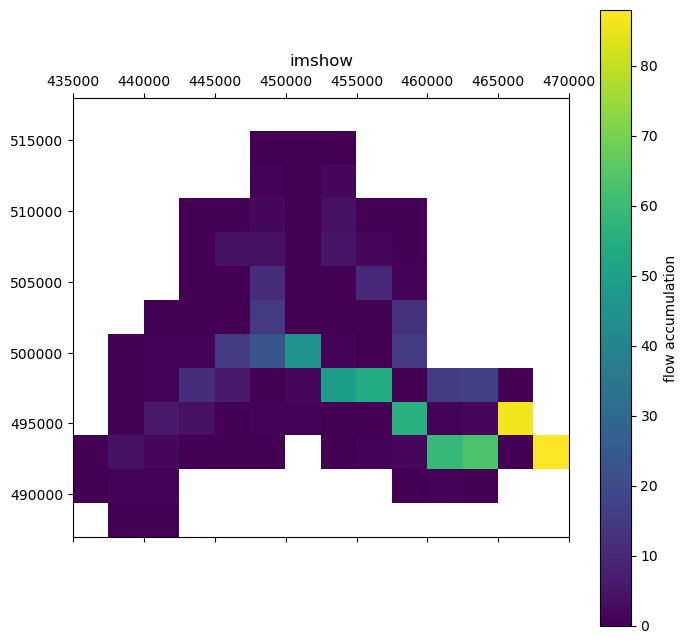

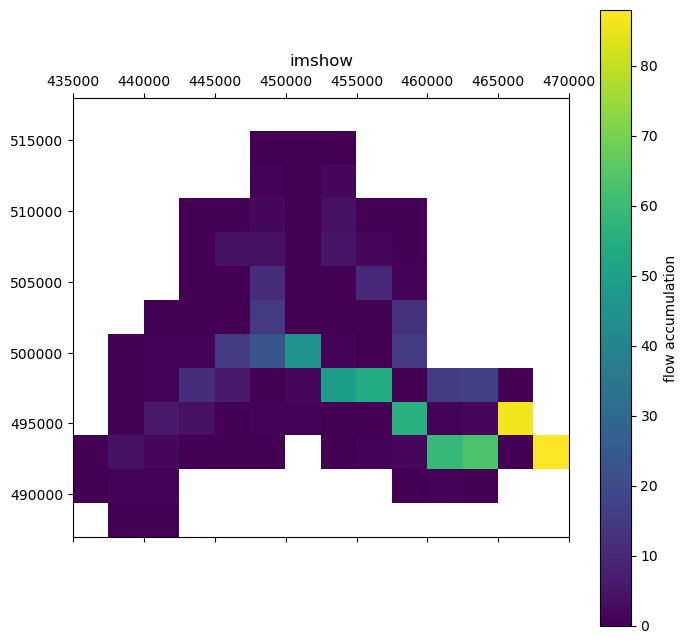

In [3]:
m = Map(crs=ds.epsg)
m.imshow(ds)
m.colorbar(label='flow accumulation')
m.set_title('imshow')
m.fig

## Filled and line contours

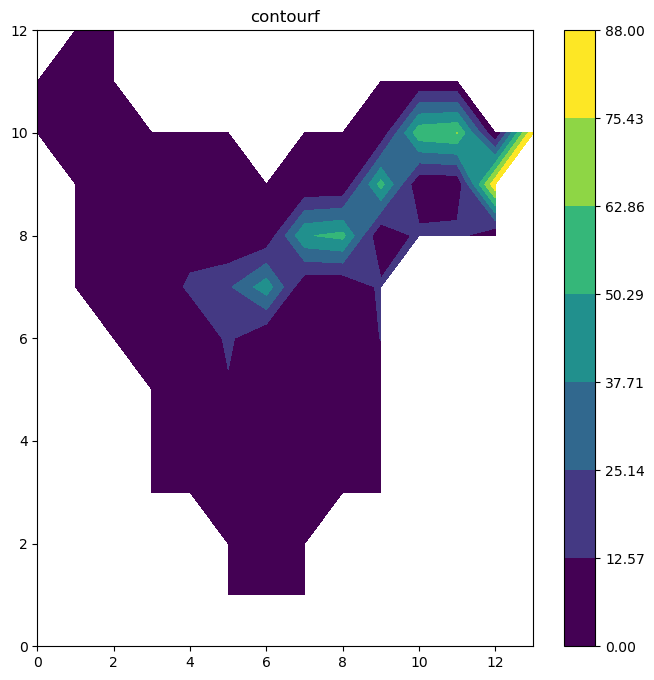

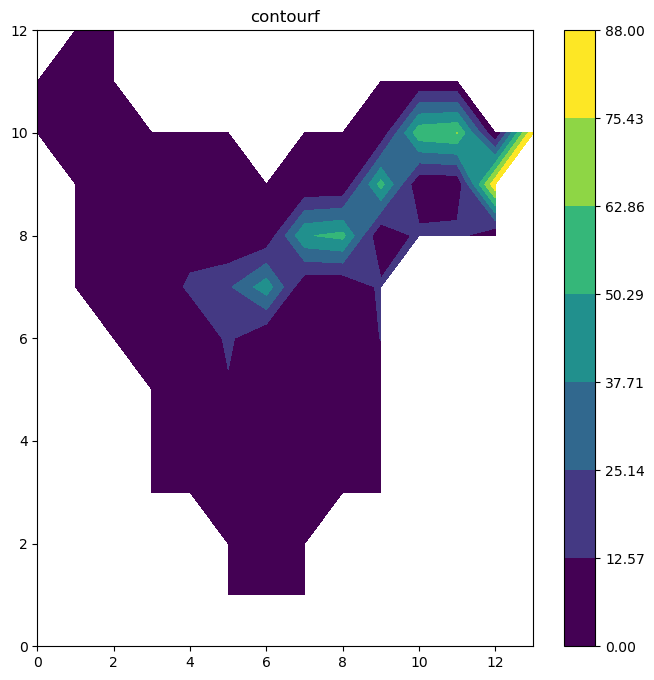

In [4]:
m = Map(crs=ds.epsg)
m.contourf(ds, levels=8)
m.colorbar()
m.set_title('contourf')
m.fig

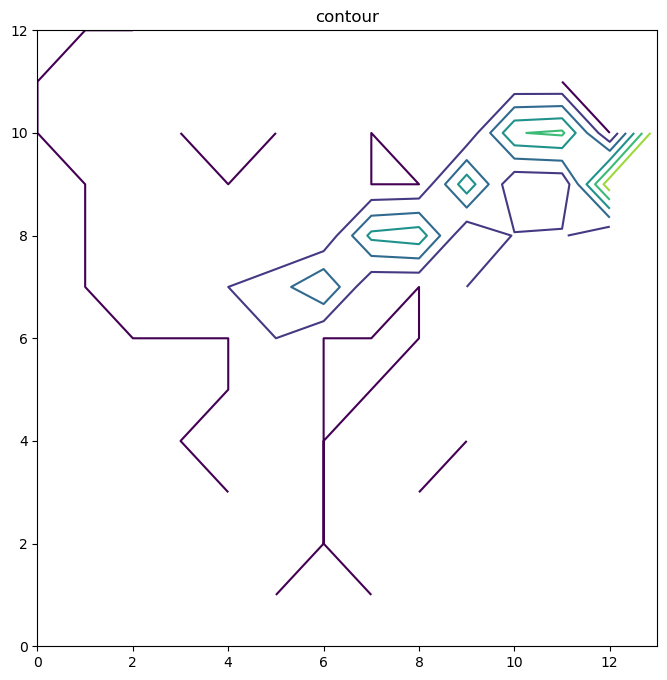

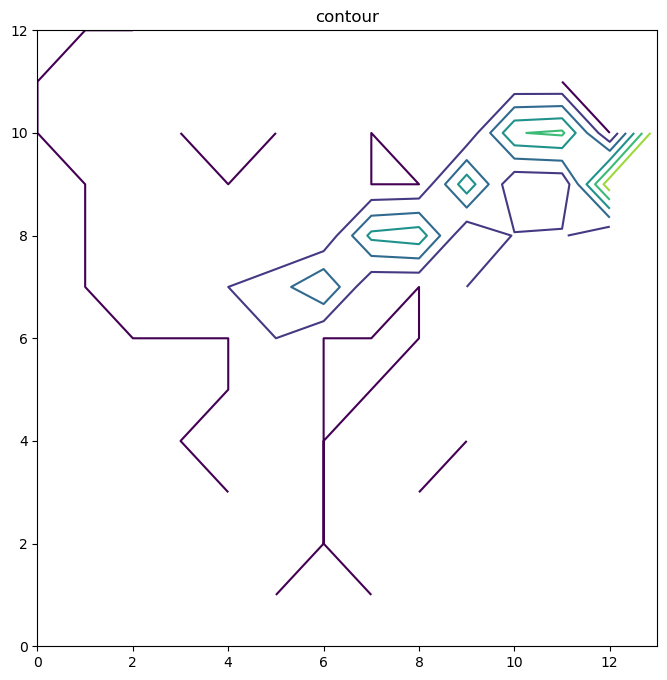

In [5]:
m = Map(crs=ds.epsg)
m.contour(ds)
m.set_title('contour')
m.fig

## pcolormesh and block

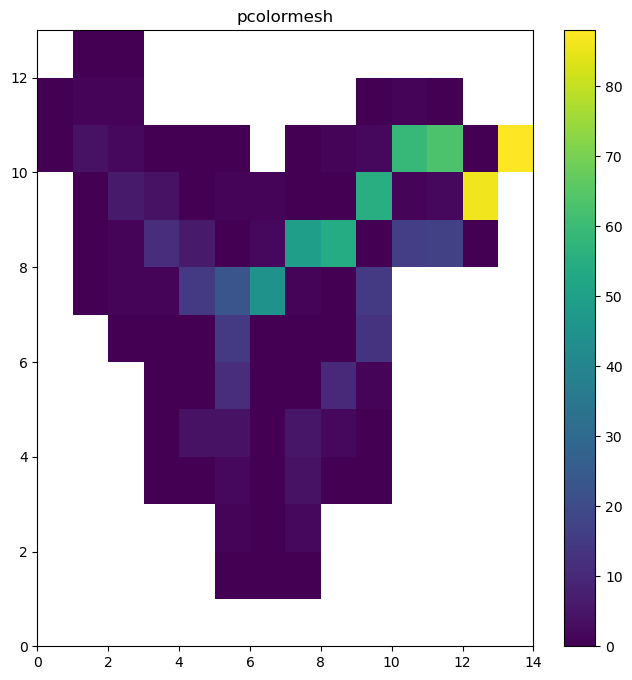

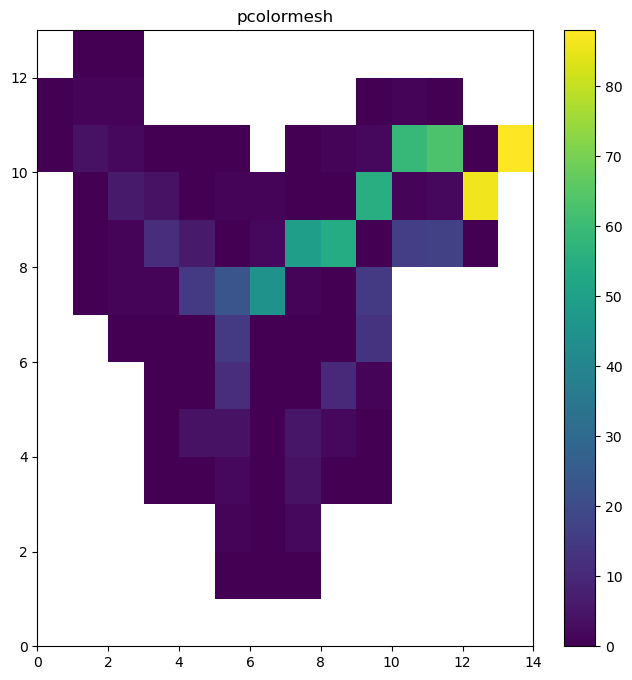

In [6]:
m = Map(crs=ds.epsg)
m.pcolormesh(ds)
m.colorbar()
m.set_title('pcolormesh')
m.fig

## Reproject to a display CRS (Web Mercator)

pyramids does the reprojection; we render on a plain axes (no Cartopy).

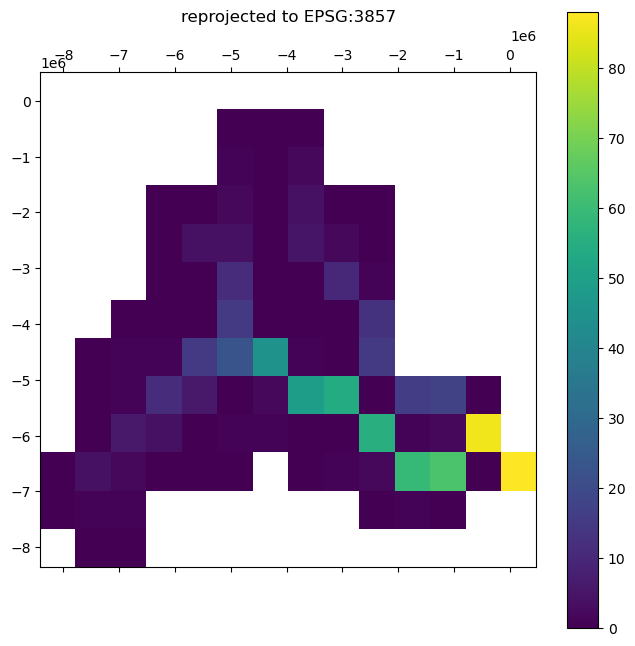

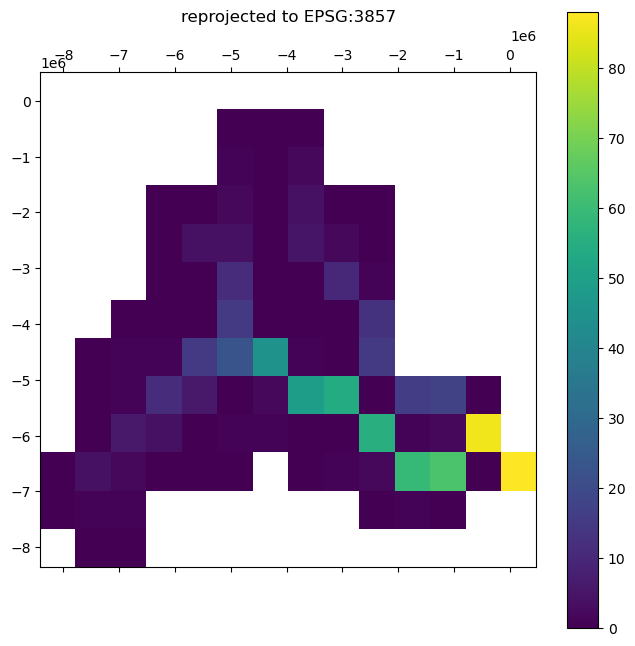

In [7]:
m = Map(crs=3857)
m.imshow(ds)
m.colorbar()
m.set_title('reprojected to EPSG:3857')
m.fig

## Auto-style by variable name

A `t2m`-named band auto-selects a temperature colormap (`coolwarm`) when you don't pass `cmap`.

auto cmap: coolwarm


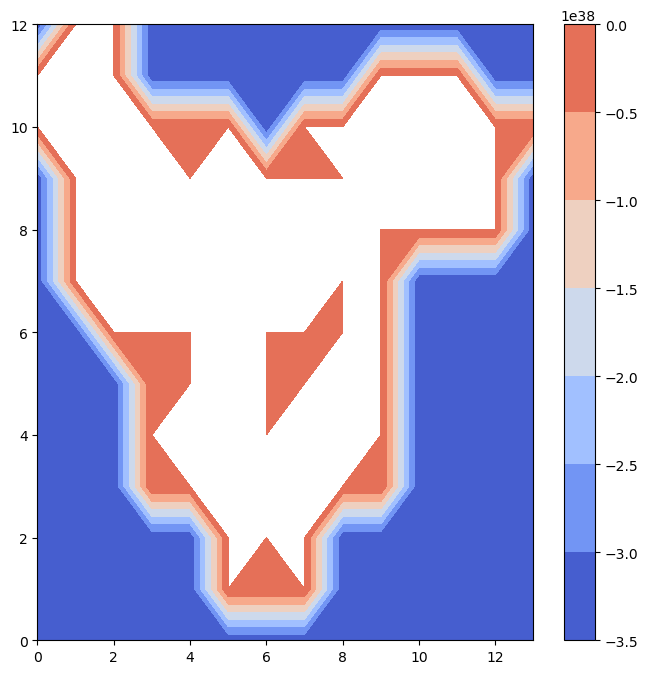

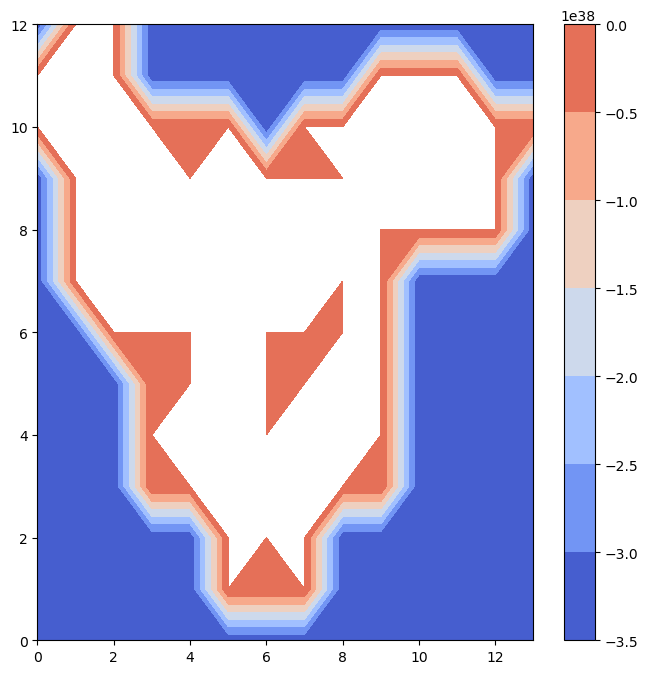

In [8]:
import numpy as np
base = np.nan_to_num(ds.read_array(band=0).astype('float32'))
t2m = Dataset.create_from_array(arr=base, geo=ds.geotransform, epsg=ds.epsg)
t2m.band_names = ['t2m']
m = Map(crs=t2m.epsg)
layer = m.contourf(t2m)
print('auto cmap:', m.layers[0][0].default_options['cmap'])
m.colorbar()
m.fig